# Differential gene expression analysis for publication Figure 4

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

from insitupy import CACHE, InSituData
from insitupy.plotting import cellular_composition

In [3]:
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

## Load Xenium data into `InSituData` object

Now the Xenium data can be parsed by providing the data path to the `InSituPy` project folder.

In [4]:
insitupy_project = Path(CACHE / "out/demo_insitupy_project")

In [5]:
xd = InSituData.read(insitupy_project)

In [6]:
xd.load_all()

In [7]:
xd.import_annotations(
    files=r"../../demo_data/demo_annotations/breast_cancer_annotations_publ.geojson",
    keys="Janesick",
    scale_factor=0.2125
)

In [8]:
xd.import_annotations(
    files=r"../../demo_data/demo_annotations/breast_cancer_annotations_Katja.geojson",
    keys="Katja",
    scale_factor=0.2125
)

In [9]:
xd.import_regions(
    files=r"../../demo_data/demo_annotations/breast_cancer_regions_Katja.geojson",
    keys="Katja",
    scale_factor=0.2125
)

In [10]:
xd

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project

    ➤ images
       CD20:	(25778, 35416)
       HE:	(25778, 35416, 3)
       HER2:	(25778, 35416)
       nuclei:	(25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 156447 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ_x', 'cell_type_publ_y', 'cell_type_dc_sub_final', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_dc_sub_final_colors', 'cell_type_p

In [11]:
xd.show()

Since only one dataset is given, all regions are plotted into one figure.


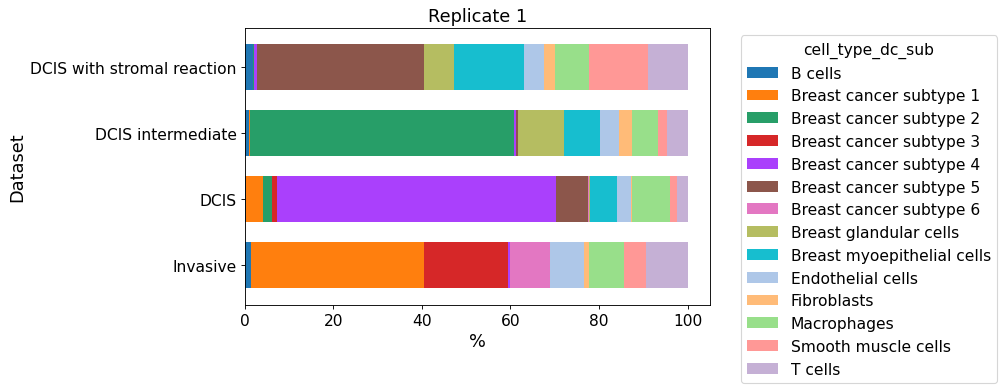

In [12]:
cellular_composition(
    data=xd, cell_type_col="cell_type_dc_sub",
    geom_key="Katja", modality="annotations", #max_cols=3,
    max_cols=1,
    plot_type="barh",
    savepath="figures/cell_composition_barh_annotations_Katja.pdf"
)

Since only one dataset is given, all regions are plotted into one figure.


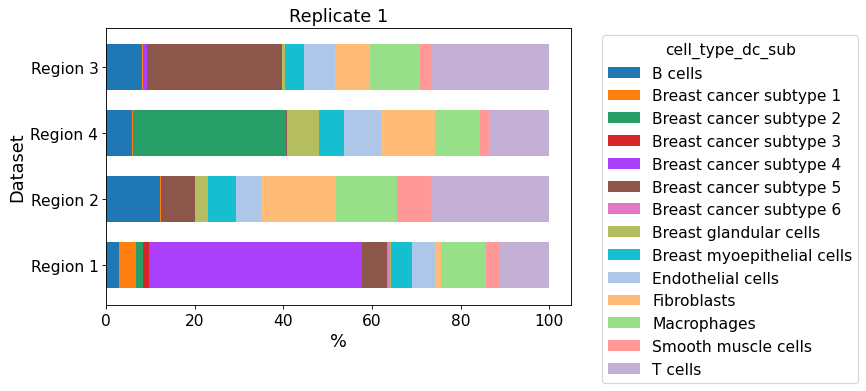

In [13]:
cellular_composition(
    data=xd, cell_type_col="cell_type_dc_sub",
    geom_key="Katja", modality="regions", #max_cols=3,
    max_cols=1,
    plot_type="barh",
    savepath="figures/cell_composition_barh_regions_Katja.pdf"
)

In [14]:
xd.save()

Saving to existing path: C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project
Updating project in C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project
	Updating cells...
	Updating annotations...
	Updating regions...
Saved.


## Next steps for DGE analysis

1. Subtype 1 and 3 in invasive tumor - 1 is in the center and 3 as outer budding layer. Also some individual tumor cells with subtype 3 found. What is the difference between the two subtypes?
    - DGE analysis within invasive Tumor annotation - subtype 3 vs. subtype 1


In [15]:
from insitupy.tools import differential_gene_expression

In [16]:
xd.show()

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


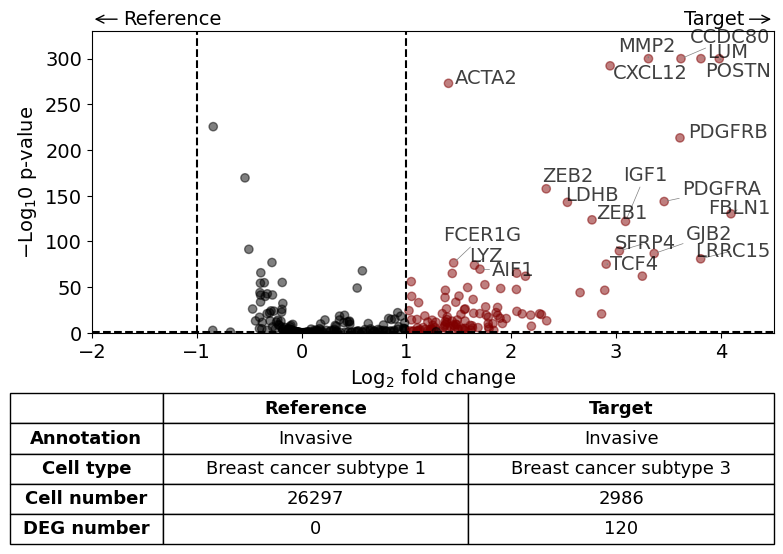

In [27]:
differential_gene_expression(
    target=xd,
    target_annotation_tuple=("Katja", "Invasive"),
    ref_annotation_tuple="same",
    target_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 3"),
    ref_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 1"),
    exclude_ambiguous_assignments=True, # in this case we are sure that there
    #savepath="figures/volcano_invasive_subtype3_vs_subtype1.pdf"
)

### Comparison of DCIS vs invasive

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


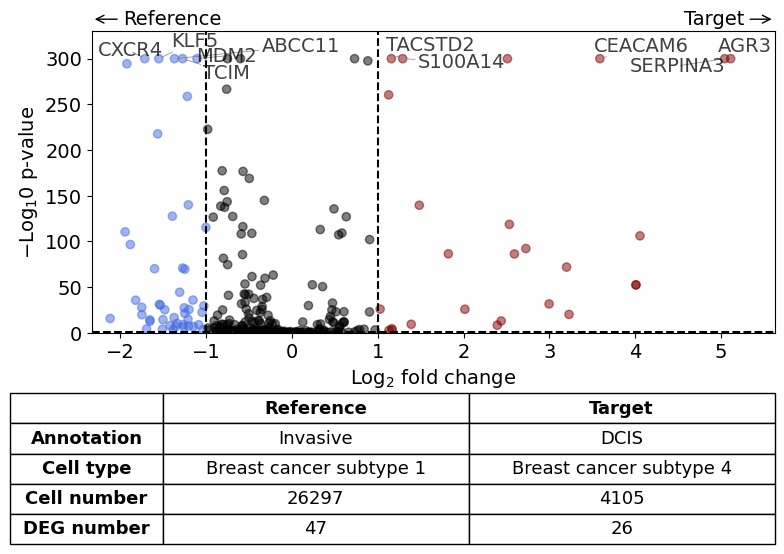

In [25]:
differential_gene_expression(
    target=xd,
    target_annotation_tuple=("Katja", "DCIS"),
    ref_annotation_tuple=("Katja", "Invasive"),
    target_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 4"),
    ref_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 1"),
    exclude_ambiguous_assignments=True, # in this case we are sure that there
    label_top_n=5,
    savepath="figures/volcano_subtype4_vs_subtype1.pdf"
)

### Comparison of DCIS vs DCIS with stromal reaction

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


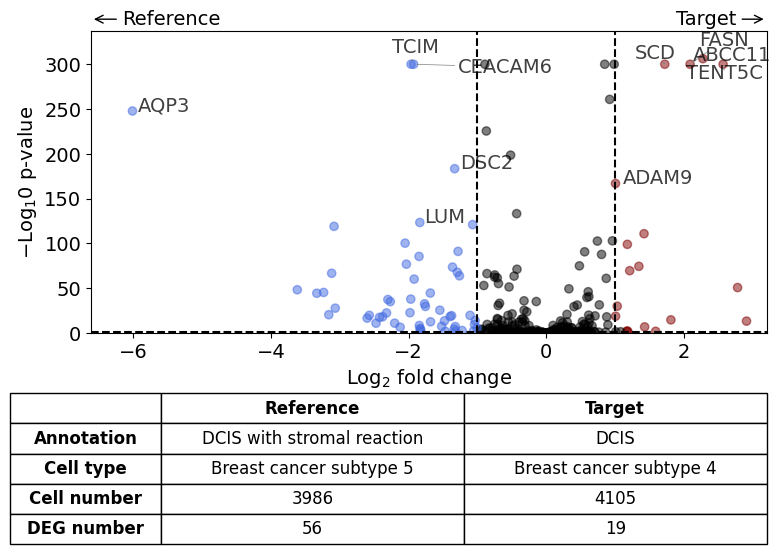

In [26]:
differential_gene_expression(
    target=xd,
    target_annotation_tuple=("Katja", "DCIS"),
    ref_annotation_tuple=("Katja", "DCIS with stromal reaction"),
    target_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 4"),
    ref_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 5"),
    exclude_ambiguous_assignments=True, # in this case we are sure that there
    label_top_n=5,
    savepath="figures/volcano_subtype4_vs_subtype5.pdf"
)

## AQP3 expression higher in subtype 5 DCIS in Region 3 compared to subtype 5 DCIS in Region 2.

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


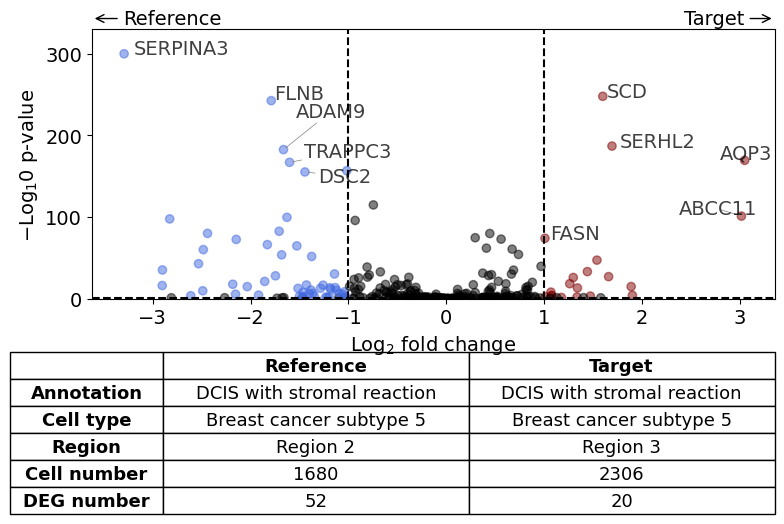

In [28]:
differential_gene_expression(
    target=xd,
    target_annotation_tuple=("Katja", "DCIS with stromal reaction"),
    ref_annotation_tuple=("Katja", "DCIS with stromal reaction"),
    target_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 5"),
    ref_cell_type_tuple="same",
    target_region_tuple=("Katja", "Region 3"),
    ref_region_tuple=("Katja", "Region 2"),
    exclude_ambiguous_assignments=True, # in this case we are sure that there
    label_top_n=5,
    savepath="figures/volcano_stromalDCIS_region3_vs_region2.pdf"
)